DATASET LOADING AND OVERVIEW
File size: 1193.88 MB


Reading file: 499999 lines [00:17, 29031.38 lines/s]



Successfully read 500000 records with 0 errors out of 500000 lines processed
Creating DataFrame from 500000 records...
Dataset shape: (50000, 2)
Memory usage: 22.45 MB

Column information:
<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 270957 to 10080
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   reviewText  50000 non-null  object 
 1   overall     50000 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.1+ MB
None

First few rows:
                                               reviewText  overall
270957  It is small, it is inexpensive and best of all...      5.0
396353  This was my first GPS and I was pleasantly sur...      4.0
296796  Great way to cobble together all my shorter co...      5.0
14990   I bought this on New Years 2006 and I used it ...      2.0
318272  I've been a fan of high quality headphones for...      5.0

Basic statistics:
           overall
count  50000.00000
mean 

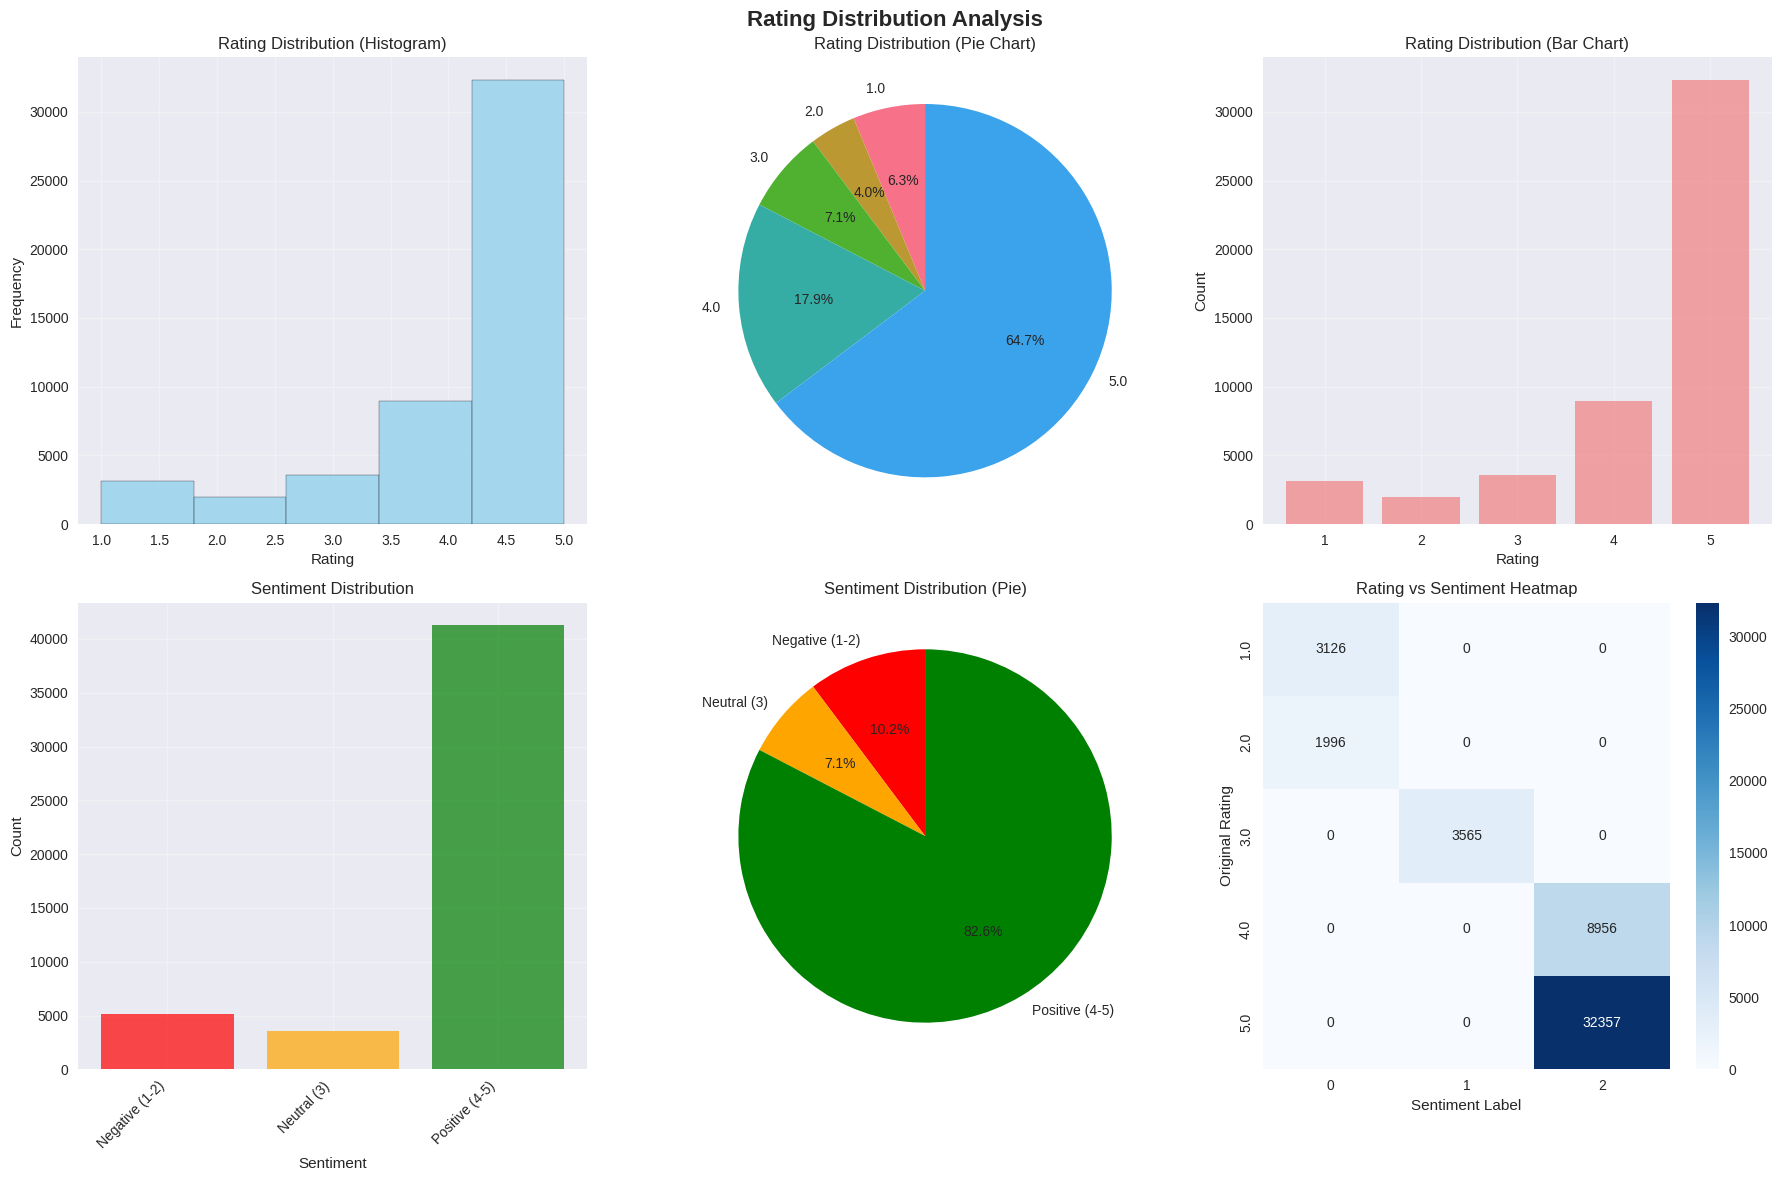


Sentiment distribution:
Negative (1-2): 5122 (10.2%)
Neutral (3): 3565 (7.1%)
Positive (4-5): 41313 (82.6%)

TEXT LENGTH ANALYSIS
Text length statistics:
count    50000.000000
mean       397.842060
std        638.748612
min          1.000000
25%         79.000000
50%        191.000000
75%        461.000000
max      20399.000000
Name: text_length, dtype: float64

Word count statistics:
count    50000.000000
mean        73.024540
std        114.916139
min          1.000000
25%         15.000000
50%         36.000000
75%         86.000000
max       3755.000000
Name: word_count, dtype: float64


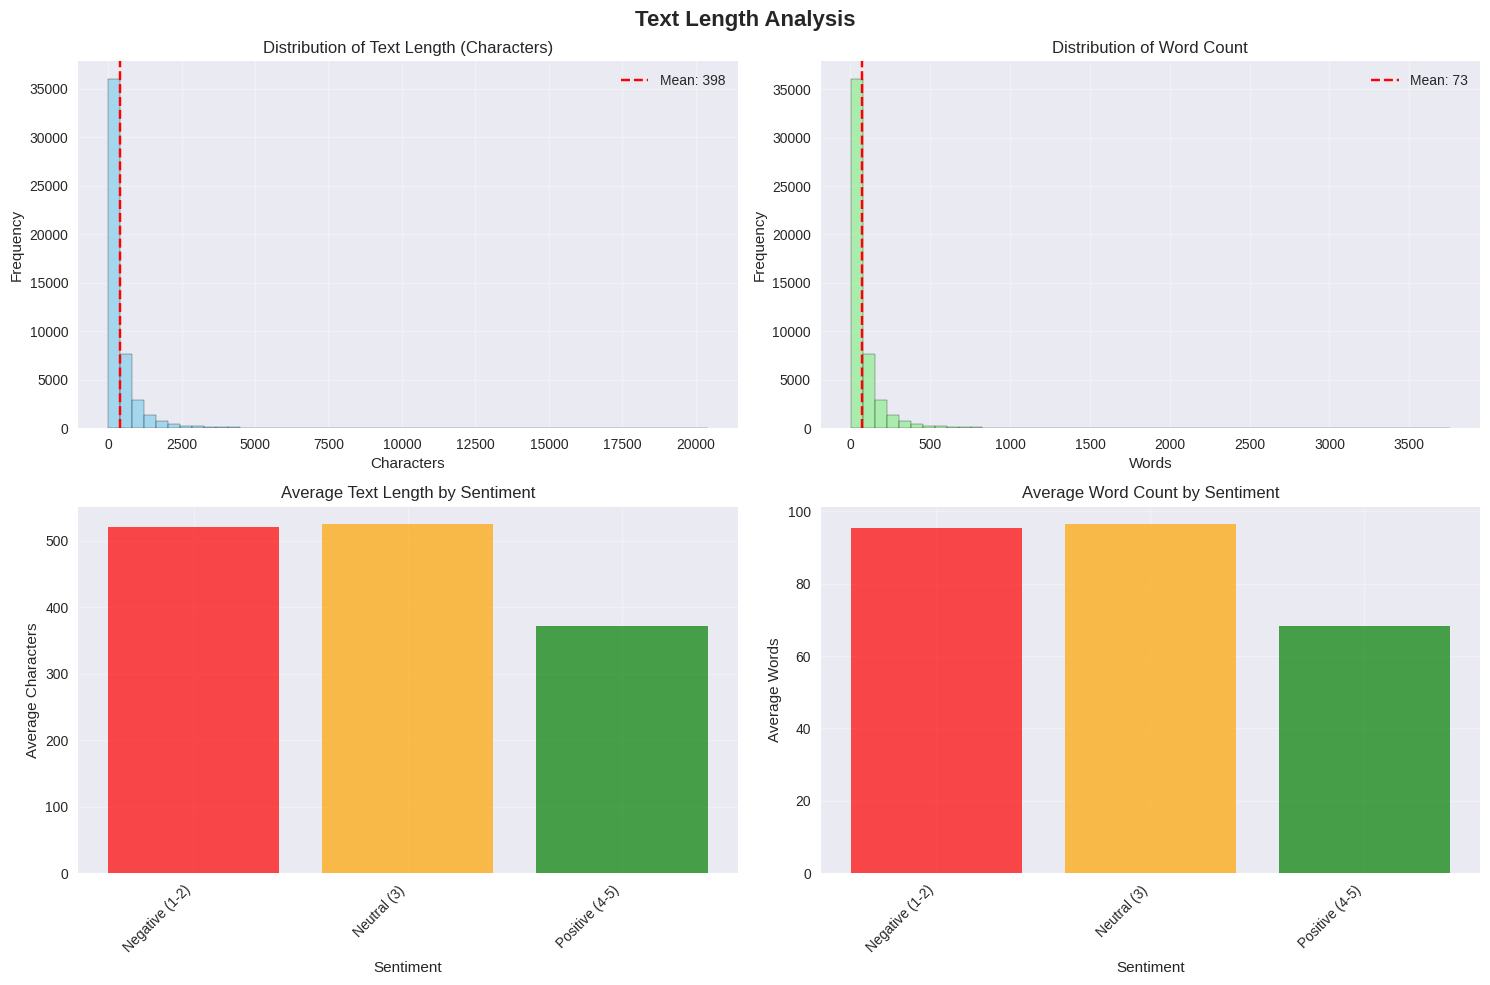


WORD CLOUD ANALYSIS


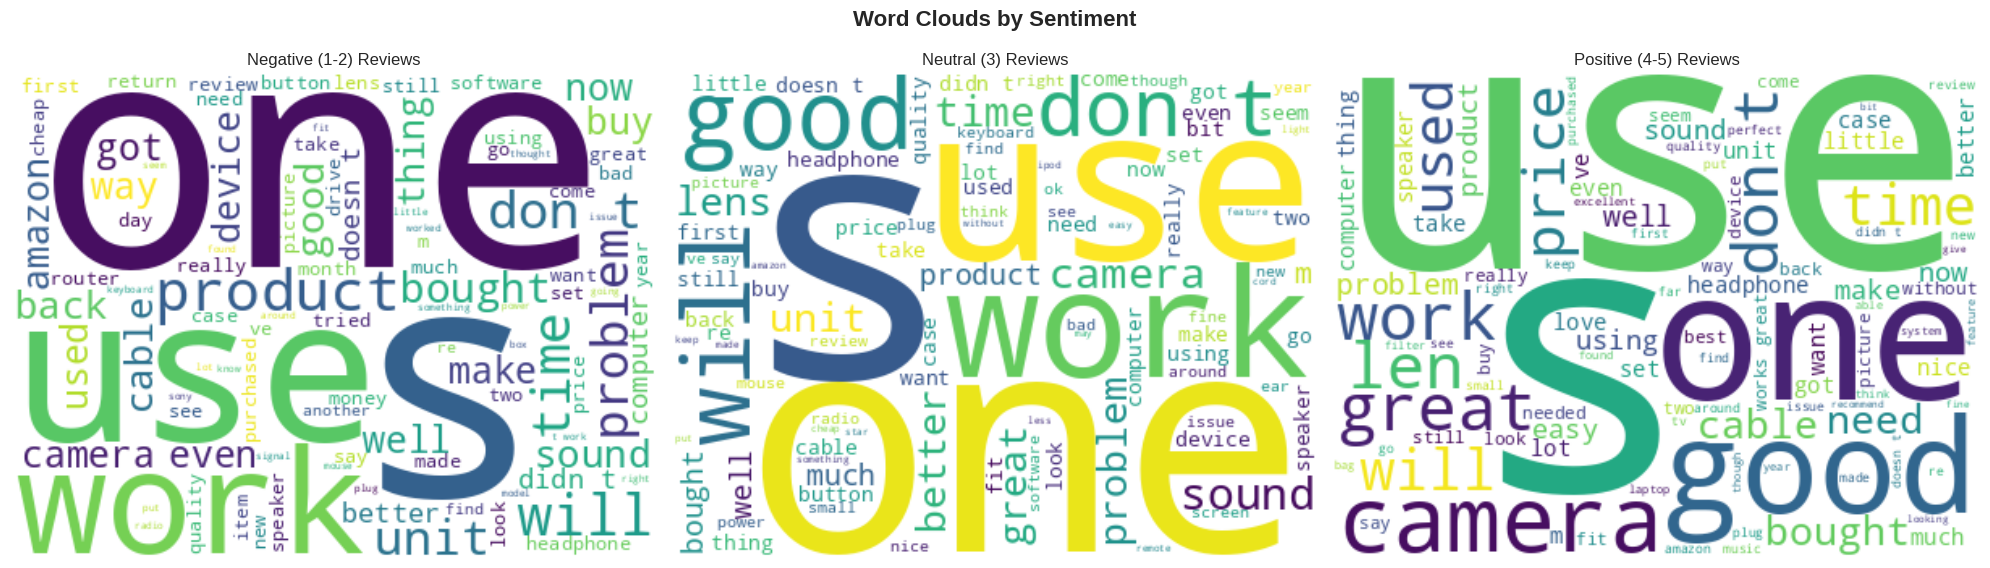


TOP WORDS ANALYSIS


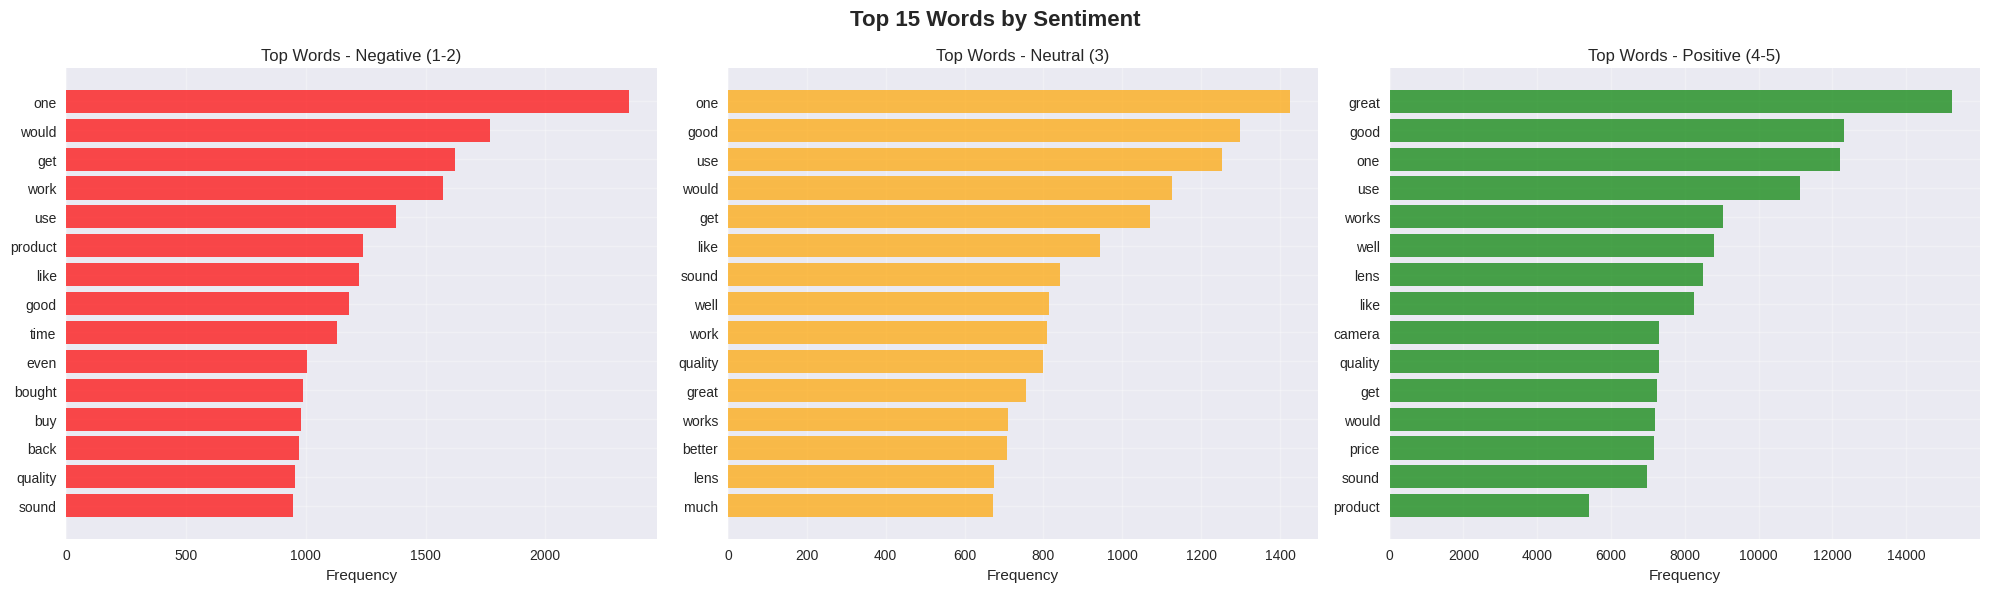


SAMPLE REVIEWS BY SENTIMENT

NEGATIVE (1-2) REVIEWS SAMPLES:
--------------------------------------------------
Sample 1: I bought this on New Years 2006 and I used it for 5 years already and the radio got static after one or two years. It lasts good on alkaline batteries but it doesn't indicate correctly like it does it...

Sample 2: Used the blower in a Pfsense box.  Unfortunately, the blower began making a terrible noise, almost like the bearings failed.  Gave it two stars since it really does cool small cases but Im not convinc...

Sample 3: Didn't need item after all and was unable to return.  Not rated for outdoor use.  Made in Vietnam...


NEUTRAL (3) REVIEWS SAMPLES:
--------------------------------------------------
Sample 1: This thing was annoying to out together, kind of flimsy but does the job....

Sample 2: I bought this just about July 28, 2008.  It's now December 28, 2009.  Technically, the mouse is still usable and functioning.

However, it's showing those signs that 

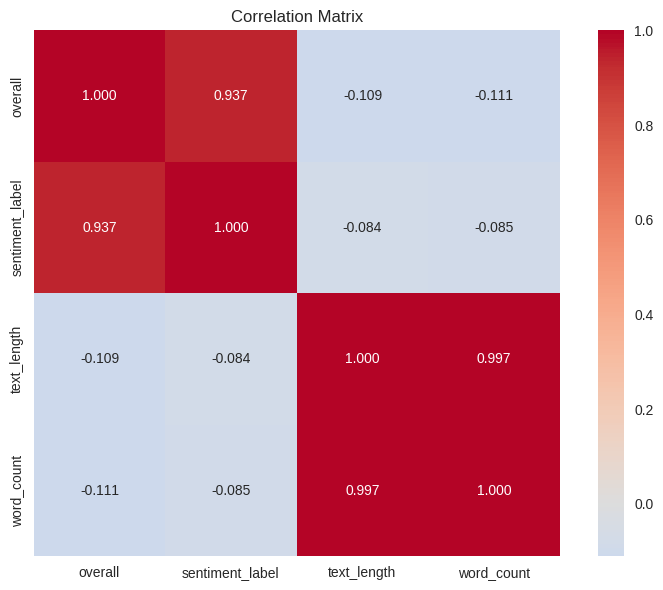

Correlation summary:
                  overall  sentiment_label  text_length  word_count
overall          1.000000         0.936649    -0.108801   -0.110816
sentiment_label  0.936649         1.000000    -0.083779   -0.085121
text_length     -0.108801        -0.083779     1.000000    0.996669
word_count      -0.110816        -0.085121     0.996669    1.000000

FINAL DATASET SUMMARY
Total reviews: 50,000
Average review length: 397.8 characters
Average word count: 73.0 words
Class imbalance ratio: 11.59:1
Data quality: 87.1% within normal range


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from wordcloud import WordCloud
import warnings
import gzip
import json
import os
from tqdm import tqdm
import nltk

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

def parse(path, max_records=500000):
    if not os.path.exists(path):
        print(f"Error: File not found at {path}")
        return []
    records = []
    error_count = 0
    line_count = 0
    try:
        with gzip.open(path, 'rb') as g:
            try:
                for line in tqdm(g, desc="Reading file", unit=" lines"):
                    line_count += 1
                    try:
                        records.append(json.loads(line.decode('utf-8')))
                        if len(records) >= max_records:
                            break
                    except (json.JSONDecodeError, UnicodeDecodeError):
                        error_count += 1
            except EOFError:
                print("\nWarning: Encountered premature end of file (EOFError).")
    except Exception as e:
        print(f"Fatal error opening file: {str(e)}")
        return []
    print(f"\nSuccessfully read {len(records)} records with {error_count} errors out of {line_count} lines processed")
    return records

def getDF(path, max_records=500000):
    records = parse(path, max_records)
    if not records:
        print("No valid records found. Returning empty DataFrame.")
        return pd.DataFrame()
    print(f"Creating DataFrame from {len(records)} records...")
    df = pd.DataFrame(records)
    expected_columns = ['reviewText', 'overall', 'summary', 'reviewerID', 'asin', 'reviewTime']
    missing = [col for col in expected_columns if col not in df.columns]
    if missing:
        print(f"Warning: Missing expected columns: {', '.join(missing)}")
        print(f"Available columns: {', '.join(df.columns)}")
    return df

print("="*80)
print("DATASET LOADING AND OVERVIEW")
print("="*80)

file_path = '/content/drive/MyDrive/ANN/Electronics_5.json.gz'
try:
    file_size = os.path.getsize(file_path) / (1024 * 1024)
    print(f"File size: {file_size:.2f} MB")
except OSError:
    print("Could not determine file size")

df = getDF(file_path, max_records=500000)
if df.empty:
    raise ValueError("Failed to load DataFrame")

df = df[['reviewText', 'overall']].copy()
df = df.dropna(subset=['reviewText', 'overall'])
df = df.sample(n=50000, random_state=42)

print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nColumn information:")
print(df.info())

print("\nFirst few rows:")
print(df.head())

print("\nBasic statistics:")
print(df.describe())

print("\n" + "="*80)
print("RATING DISTRIBUTION ANALYSIS")
print("="*80)

print("Overall rating distribution:")
print(df['overall'].value_counts().sort_index())

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Rating Distribution Analysis', fontsize=16, fontweight='bold')

axes[0, 0].hist(df['overall'], bins=5, color='skyblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Rating Distribution (Histogram)')
axes[0, 0].set_xlabel('Rating')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

rating_counts = df['overall'].value_counts().sort_index()
axes[0, 1].pie(rating_counts.values, labels=rating_counts.index, autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Rating Distribution (Pie Chart)')

axes[0, 2].bar(rating_counts.index, rating_counts.values, color='lightcoral', alpha=0.7)
axes[0, 2].set_title('Rating Distribution (Bar Chart)')
axes[0, 2].set_xlabel('Rating')
axes[0, 2].set_ylabel('Count')
axes[0, 2].grid(True, alpha=0.3)

df['sentiment_label'] = df['overall'].apply(lambda x: 0 if x <= 2 else 1 if x == 3 else 2)
sentiment_counts = df['sentiment_label'].value_counts().sort_index()
sentiment_labels = ['Negative (1-2)', 'Neutral (3)', 'Positive (4-5)']

axes[1, 0].bar(range(len(sentiment_counts)), sentiment_counts.values,
               color=['red', 'orange', 'green'], alpha=0.7)
axes[1, 0].set_title('Sentiment Distribution')
axes[1, 0].set_xlabel('Sentiment')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_xticks(range(len(sentiment_labels)))
axes[1, 0].set_xticklabels(sentiment_labels, rotation=45, ha='right')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].pie(sentiment_counts.values, labels=sentiment_labels, autopct='%1.1f%%',
               colors=['red', 'orange', 'green'], startangle=90)
axes[1, 1].set_title('Sentiment Distribution (Pie)')

rating_sentiment_crosstab = pd.crosstab(df['overall'], df['sentiment_label'])
sns.heatmap(rating_sentiment_crosstab, annot=True, fmt='d', cmap='Blues', ax=axes[1, 2])
axes[1, 2].set_title('Rating vs Sentiment Heatmap')
axes[1, 2].set_xlabel('Sentiment Label')
axes[1, 2].set_ylabel('Original Rating')

plt.tight_layout()
plt.show()

print("\nSentiment distribution:")
for i, label in enumerate(sentiment_labels):
    print(f"{label}: {sentiment_counts[i]} ({sentiment_counts[i]/len(df)*100:.1f}%)")

print("\n" + "="*80)
print("TEXT LENGTH ANALYSIS")
print("="*80)

df['text_length'] = df['reviewText'].str.len()
df['word_count'] = df['reviewText'].str.split().str.len()

print("Text length statistics:")
print(df['text_length'].describe())
print("\nWord count statistics:")
print(df['word_count'].describe())

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Text Length Analysis', fontsize=16, fontweight='bold')

axes[0, 0].hist(df['text_length'], bins=50, color='skyblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Distribution of Text Length (Characters)')
axes[0, 0].set_xlabel('Characters')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df['text_length'].mean(), color='red', linestyle='--', label=f'Mean: {df["text_length"].mean():.0f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(df['word_count'], bins=50, color='lightgreen', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Distribution of Word Count')
axes[0, 1].set_xlabel('Words')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(df['word_count'].mean(), color='red', linestyle='--', label=f'Mean: {df["word_count"].mean():.0f}')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

sentiment_text_length = df.groupby('sentiment_label')['text_length'].mean()
axes[1, 0].bar(range(len(sentiment_text_length)), sentiment_text_length.values,
               color=['red', 'orange', 'green'], alpha=0.7)
axes[1, 0].set_title('Average Text Length by Sentiment')
axes[1, 0].set_xlabel('Sentiment')
axes[1, 0].set_ylabel('Average Characters')
axes[1, 0].set_xticks(range(len(sentiment_labels)))
axes[1, 0].set_xticklabels(sentiment_labels, rotation=45, ha='right')
axes[1, 0].grid(True, alpha=0.3)

sentiment_word_count = df.groupby('sentiment_label')['word_count'].mean()
axes[1, 1].bar(range(len(sentiment_word_count)), sentiment_word_count.values,
               color=['red', 'orange', 'green'], alpha=0.7)
axes[1, 1].set_title('Average Word Count by Sentiment')
axes[1, 1].set_xlabel('Sentiment')
axes[1, 1].set_ylabel('Average Words')
axes[1, 1].set_xticks(range(len(sentiment_labels)))
axes[1, 1].set_xticklabels(sentiment_labels, rotation=45, ha='right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("WORD CLOUD ANALYSIS")
print("="*80)

def preprocess_for_wordcloud(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_text_wc'] = df['reviewText'].apply(preprocess_for_wordcloud)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Word Clouds by Sentiment', fontsize=16, fontweight='bold')

for i, (sentiment, label) in enumerate(zip([0, 1, 2], sentiment_labels)):
    sentiment_text = ' '.join(df[df['sentiment_label'] == sentiment]['cleaned_text_wc'].values)
    if sentiment_text.strip():
        wordcloud = WordCloud(width=400, height=300, background_color='white',
                            max_words=100, colormap='viridis').generate(sentiment_text)
        axes[i].imshow(wordcloud, interpolation='bilinear')
        axes[i].set_title(f'{label} Reviews')
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, 'No data', ha='center', va='center', transform=axes[i].transAxes)
        axes[i].set_title(f'{label} Reviews')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("TOP WORDS ANALYSIS")
print("="*80)

try:
    nltk.download('stopwords', quiet=True)
    from nltk.corpus import stopwords
    stop_words = set(stopwords.words('english'))
except:
    stop_words = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by', 'this', 'that', 'it', 'is', 'was', 'are', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 'could', 'should', 'may', 'might', 'must', 'can', 'i', 'you', 'he', 'she', 'we', 'they', 'me', 'him', 'her', 'us', 'them', 'my', 'your', 'his', 'our', 'their'}

def get_top_words(text_series, n=20):
    all_words = []
    for text in text_series:
        if isinstance(text, str):
            words = text.lower().split()
            words = [word for word in words if word not in stop_words and len(word) > 2]
            all_words.extend(words)
    return Counter(all_words).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Top 15 Words by Sentiment', fontsize=16, fontweight='bold')

for i, (sentiment, label) in enumerate(zip([0, 1, 2], sentiment_labels)):
    sentiment_reviews = df[df['sentiment_label'] == sentiment]['cleaned_text_wc']
    top_words = get_top_words(sentiment_reviews, 15)

    if top_words:
        words, counts = zip(*top_words)
        axes[i].barh(range(len(words)), counts, color=['red', 'orange', 'green'][i], alpha=0.7)
        axes[i].set_yticks(range(len(words)))
        axes[i].set_yticklabels(words)
        axes[i].set_xlabel('Frequency')
        axes[i].set_title(f'Top Words - {label}')
        axes[i].invert_yaxis()
        axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("SAMPLE REVIEWS BY SENTIMENT")
print("="*80)

for sentiment, label in zip([0, 1, 2], sentiment_labels):
    print(f"\n{label.upper()} REVIEWS SAMPLES:")
    print("-" * 50)
    samples = df[df['sentiment_label'] == sentiment]['reviewText'].head(3)
    for idx, review in enumerate(samples, 1):
        print(f"Sample {idx}: {review[:200]}...")
        print()

print("\n" + "="*80)
print("DATA QUALITY ANALYSIS")
print("="*80)

print("Missing values:")
print(df.isnull().sum())

print(f"\nDuplicate reviews: {df.duplicated().sum()}")

print(f"\nReviews with very short text (< 10 characters): {(df['text_length'] < 10).sum()}")
print(f"Percentage: {(df['text_length'] < 10).sum() / len(df) * 100:.2f}%")

print(f"\nReviews with very long text (> 1000 characters): {(df['text_length'] > 1000).sum()}")
print(f"Percentage: {(df['text_length'] > 1000).sum() / len(df) * 100:.2f}%")

print("\n" + "="*80)
print("CORRELATION ANALYSIS")
print("="*80)

correlation_df = df[['overall', 'sentiment_label', 'text_length', 'word_count']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_df, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

print("Correlation summary:")
print(correlation_df)

print("\n" + "="*80)
print("FINAL DATASET SUMMARY")
print("="*80)

print(f"Total reviews: {len(df):,}")
print(f"Average review length: {df['text_length'].mean():.1f} characters")
print(f"Average word count: {df['word_count'].mean():.1f} words")
print(f"Class imbalance ratio: {max(sentiment_counts) / min(sentiment_counts):.2f}:1")
print(f"Data quality: {((df['text_length'] >= 10) & (df['text_length'] <= 1000)).sum() / len(df) * 100:.1f}% within normal range")

File size: 1193.88 MB


Reading file: 499999 lines [00:07, 70611.77 lines/s]



Successfully read 500000 records with 0 errors out of 500000 lines processed
Creating DataFrame from 500000 records...

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 270957 to 10080
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   reviewText  50000 non-null  object 
 1   overall     50000 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.1+ MB
None

First 5 rows:
                                               reviewText  overall
270957  It is small, it is inexpensive and best of all...      5.0
396353  This was my first GPS and I was pleasantly sur...      4.0
296796  Great way to cobble together all my shorter co...      5.0
14990   I bought this on New Years 2006 and I used it ...      2.0
318272  I've been a fan of high quality headphones for...      5.0

Class distribution before balancing:
sentiment_label
2    41313
0     5122
1     3565
Name: count, dtype: int64

Cla

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

...

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 258s 235ms/step - accuracy: 0.9358 - loss: 0.2491 - precision: 0.9402 - recall: 0.9309 - val_accuracy: 0.8956 - val_loss: 0.3712 - val_precision: 0.8996 - val_recall: 0.8892 - learning_rate: 0.0010
Epoch 9/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.9438 - loss: 0.2147 - precision: 0.9488 - recall: 0.9386
Epoch 9: val_accuracy improved from 0.89560 to 0.89680, saving model to best_model.h5


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 256s 234ms/step - accuracy: 0.9438 - loss: 0.2147 - precision: 0.9488 - recall: 0.9386 - val_accuracy: 0.8968 - val_loss: 0.3874 - val_precision: 0.9003 - val_recall: 0.8951 - learning_rate: 0.0010
Epoch 10/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9503 - loss: 0.1977 - precision: 0.9539 - recall: 0.9459
Epoch 10: val_accuracy improved from 0.89680 to 0.90107, saving model to best_model.h5


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 262s 239ms/step - accuracy: 0.9503 - loss: 0.1977 - precision: 0.9539 - recall: 0.9459 - val_accuracy: 0.9011 - val_loss: 0.3636 - val_precision: 0.9040 - val_recall: 0.8977 - learning_rate: 0.0010
Epoch 11/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.9554 - loss: 0.1804 - precision: 0.9587 - recall: 0.9516
Epoch 11: val_accuracy did not improve from 0.90107
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 259s 237ms/step - accuracy: 0.9554 - loss: 0.1804 - precision: 0.9587 - recall: 0.9516 - val_accuracy: 0.8804 - val_loss: 0.4406 - val_precision: 0.8837 - val_recall: 0.8744 - learning_rate: 0.0010
Epoch 12/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.9580 - loss: 0.1747 - precision: 0.9611 - recall: 0.9550
Epoch 12: val_accuracy improved from 0.90107 to 0.91267, saving model to best_model.h5


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 259s 234ms/step - accuracy: 0.9580 - loss: 0.1747 - precision: 0.9611 - recall: 0.9550 - val_accuracy: 0.9127 - val_loss: 0.3685 - val_precision: 0.9148 - val_recall: 0.9104 - learning_rate: 0.0010
Epoch 13/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.9616 - loss: 0.1564 - precision: 0.9643 - recall: 0.9582
Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 13: val_accuracy did not improve from 0.91267
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 260s 238ms/step - accuracy: 0.9616 - loss: 0.1564 - precision: 0.9643 - recall: 0.9582 - val_accuracy: 0.8872 - val_loss: 0.4368 - val_precision: 0.8950 - val_recall: 0.8793 - learning_rate: 0.0010
Epoch 14/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.9710 - loss: 0.1266 - precision: 0.9727 - recall: 0.9684
Epoch 14: val_accuracy did not improve from 0.91267
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 260s 238ms/step - accuracy: 0.9710 - loss: 0.1266 - precision: 0.9727 - r

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 264s 240ms/step - accuracy: 0.9815 - loss: 0.0759 - precision: 0.9834 - recall: 0.9801 - val_accuracy: 0.9147 - val_loss: 0.4187 - val_precision: 0.9164 - val_recall: 0.9129 - learning_rate: 9.0000e-05
Epoch 17: early stopping
Restoring model weights from the end of the best epoch: 10.

Training completed in 4428.61 seconds


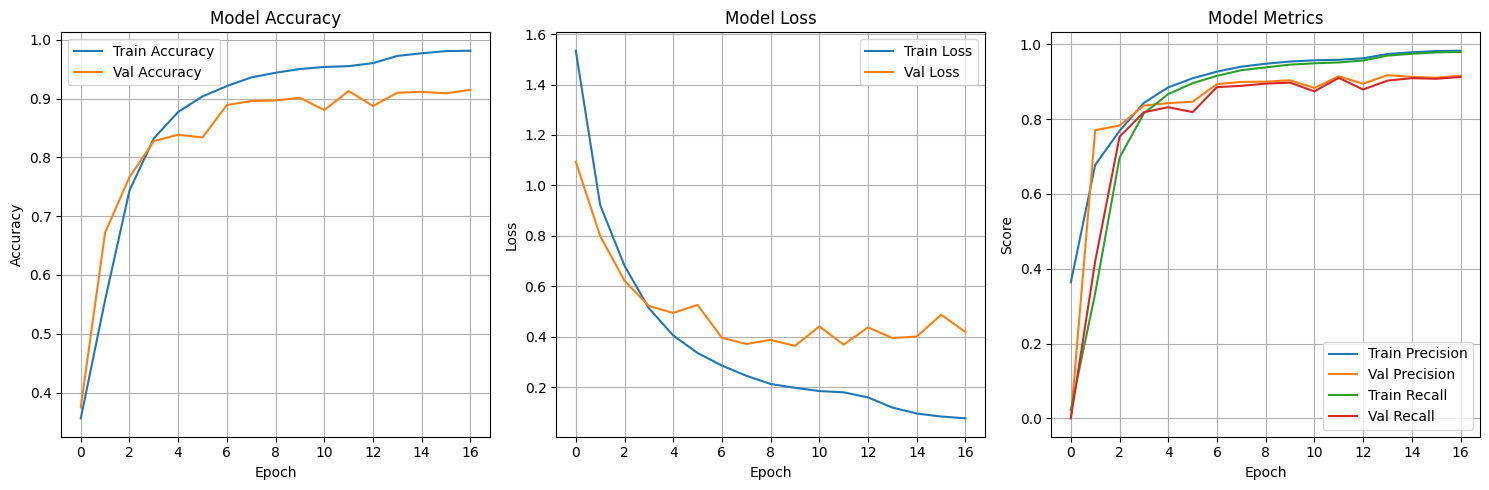

Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.93      0.93      2500
     Neutral       0.86      0.93      0.89      2500
    Positive       0.92      0.85      0.88      2500

    accuracy                           0.90      7500
   macro avg       0.91      0.90      0.90      7500
weighted avg       0.91      0.90      0.90      7500



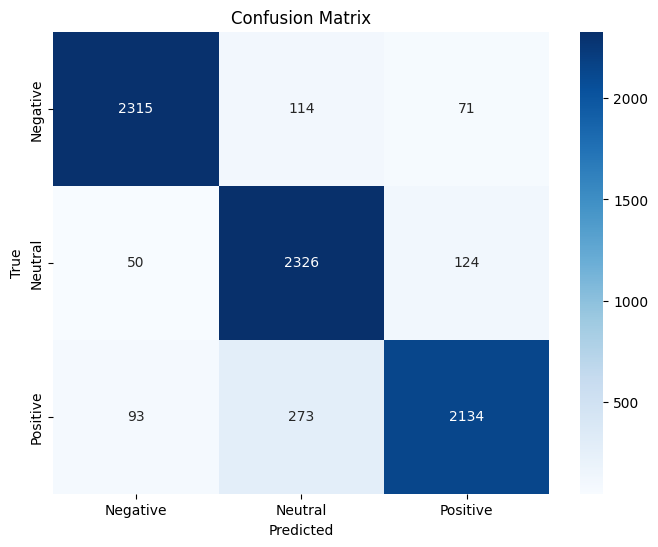


Sample Predictions:
Review: This product is absolutely amazing! Great quality and fast shipping.
Predicted: Positive (confidence: 0.981)
Probabilities: [0.00275171 0.01611864 0.9811296 ]
Inference time: 0.1946 seconds

Review: The product is decent, nothing spectacular but does what it's supposed to do.
Predicted: Neutral (confidence: 0.998)
Probabilities: [8.4779511e-04 9.9767059e-01 1.4816991e-03]
Inference time: 0.1071 seconds

Review: Terrible quality, broke after 2 days. Complete waste of money!
Predicted: Negative (confidence: 0.997)
Probabilities: [0.9967409  0.00185071 0.00140837]
Inference time: 0.1041 seconds



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import time
from wordcloud import WordCloud
import gzip
import json
import os
from tqdm import tqdm
from imblearn.over_sampling import SMOTE
from collections import Counter

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'[^a-zA-Z0-9\s!?.,]', '', text)
    return text

def balance_dataset(X, y, strategy='combined'):
    if strategy == 'undersample':
        class_counts = Counter(y)
        min_count = min(class_counts.values())

        balanced_X, balanced_y = [], []
        for class_label in class_counts.keys():
            class_indices = np.where(y == class_label)[0]
            selected_indices = np.random.choice(class_indices, min_count, replace=False)
            balanced_X.extend([X[i] for i in selected_indices])
            balanced_y.extend([y[i] for i in selected_indices])

        return np.array(balanced_X), np.array(balanced_y)

    elif strategy == 'oversample':
        class_counts = Counter(y)
        max_count = max(class_counts.values())

        balanced_X, balanced_y = [], []
        for class_label in class_counts.keys():
            class_indices = np.where(y == class_label)[0]
            class_X = [X[i] for i in class_indices]
            class_y = [y[i] for i in class_indices]

            oversample_indices = np.random.choice(len(class_X), max_count, replace=True)
            balanced_X.extend([class_X[i] for i in oversample_indices])
            balanced_y.extend([class_y[i] for i in oversample_indices])

        return np.array(balanced_X), np.array(balanced_y)

    elif strategy == 'combined':
        class_counts = Counter(y)
        target_count = int(np.mean(list(class_counts.values())))

        balanced_X, balanced_y = [], []
        for class_label in class_counts.keys():
            class_indices = np.where(y == class_label)[0]
            class_X = [X[i] for i in class_indices]
            class_y = [y[i] for i in class_indices]

            if len(class_X) > target_count:
                selected_indices = np.random.choice(len(class_X), target_count, replace=False)
            else:
                selected_indices = np.random.choice(len(class_X), target_count, replace=True)

            balanced_X.extend([class_X[i] for i in selected_indices])
            balanced_y.extend([class_y[i] for i in selected_indices])

        return np.array(balanced_X), np.array(balanced_y)

def create_model(vocab_size, embedding_dim, max_sequence_length):
    model = Sequential([
        Embedding(input_dim=vocab_size,
                 output_dim=embedding_dim,
                 input_length=max_sequence_length,
                 trainable=True),

        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),

        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),

        LSTM(units=100, dropout=0.3, recurrent_dropout=0.3, return_sequences=False),
        BatchNormalization(),

        Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.5),
        Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.3),
        Dense(3, activation='softmax')
    ])

    return model

def train_model(model, X_train, y_train, X_val, y_val, class_weights, epochs=50):
    model.compile(
        optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
        loss='categorical_crossentropy',
        metrics=['accuracy', 'precision', 'recall']
    )

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )

    model_checkpoint = ModelCheckpoint(
        'best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=32,
        class_weight=class_weights,
        callbacks=[early_stopping, reduce_lr, model_checkpoint],
        verbose=1
    )

    return history

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_test_classes = np.argmax(y_test, axis=1)

    print("Classification Report:")
    print(classification_report(y_test_classes, y_pred_classes,
                              target_names=['Negative', 'Neutral', 'Positive'],
                              zero_division=0))

    cm = confusion_matrix(y_test_classes, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d',
               xticklabels=['Negative', 'Neutral', 'Positive'],
               yticklabels=['Negative', 'Neutral', 'Positive'],
               cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return y_pred, y_pred_classes, y_test_classes

def plot_training_history(history):
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(history.history['precision'], label='Train Precision')
    plt.plot(history.history['val_precision'], label='Val Precision')
    plt.plot(history.history['recall'], label='Train Recall')
    plt.plot(history.history['val_recall'], label='Val Recall')
    plt.title('Model Metrics')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def predict_sentiment(text, model, tokenizer, max_len=256):
    cleaned_text = preprocess_text(text)
    sequence = tokenizer.texts_to_sequences([cleaned_text])
    padded_sequence = pad_sequences(sequence, maxlen=max_len, padding='post')

    start_time = time.time()
    prediction = model.predict(padded_sequence, verbose=0)
    inference_time = time.time() - start_time

    sentiment = np.argmax(prediction)
    confidence = prediction[0][sentiment]

    return sentiment, confidence, prediction[0], inference_time

def parse(path, max_records=500000):
    if not os.path.exists(path):
        print(f"Error: File not found at {path}")
        return []
    records = []
    error_count = 0
    line_count = 0
    try:
        with gzip.open(path, 'rb') as g:
            try:
                for line in tqdm(g, desc="Reading file", unit=" lines"):
                    line_count += 1
                    try:
                        records.append(json.loads(line.decode('utf-8')))
                        if len(records) >= max_records:
                            break
                    except (json.JSONDecodeError, UnicodeDecodeError):
                        error_count += 1
            except EOFError:
                print("\nWarning: Encountered premature end of file (EOFError).")
    except Exception as e:
        print(f"Fatal error opening file: {str(e)}")
        return []
    print(f"\nSuccessfully read {len(records)} records with {error_count} errors out of {line_count} lines processed")
    return records

def getDF(path, max_records=500000):
    records = parse(path, max_records)
    if not records:
        print("No valid records found. Returning empty DataFrame.")
        return pd.DataFrame()
    print(f"Creating DataFrame from {len(records)} records...")
    df = pd.DataFrame(records)
    expected_columns = ['reviewText', 'overall', 'summary', 'reviewerID', 'asin', 'reviewTime']
    missing = [col for col in expected_columns if col not in df.columns]
    if missing:
        print(f"Warning: Missing expected columns: {', '.join(missing)}")
        print(f"Available columns: {', '.join(df.columns)}")
    return df

file_path = 'Electronics_5.json.gz'
try:
    file_size = os.path.getsize(file_path) / (1024 * 1024)
    print(f"File size: {file_size:.2f} MB")
except OSError:
    print("Could not determine file size")

df = getDF(file_path, max_records=500000)
if df.empty:
    raise ValueError("Failed to load DataFrame")

df = df[['reviewText', 'overall']].copy()
df = df.dropna(subset=['reviewText', 'overall'])
df = df.sample(n=50000, random_state=42)

print("\nDataFrame Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

df['sentiment_label'] = df['overall'].apply(lambda x: 0 if x <= 2 else 1 if x == 3 else 2)
df['cleaned_text'] = df['reviewText'].apply(preprocess_text)

print("\nClass distribution before balancing:")
print(df['sentiment_label'].value_counts())

balanced_texts, balanced_labels = balance_dataset(
    df['cleaned_text'].values,
    df['sentiment_label'].values,
    strategy='combined'
)

print("\nClass distribution after balancing:")
print(Counter(balanced_labels))

MAX_VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 256
EMBEDDING_DIM = 128

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(balanced_texts)

sequences = tokenizer.texts_to_sequences(balanced_texts)
padded_sequences = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
labels = to_categorical(balanced_labels, num_classes=3)

X_train, X_temp, y_train, y_temp = train_test_split(
    padded_sequences, labels, test_size=0.3, stratify=labels, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"\nDataset shapes:")
print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

class_weight_dict = compute_class_weight(
    'balanced',
    classes=np.unique(balanced_labels),
    y=balanced_labels
)
class_weight_dict = dict(enumerate(class_weight_dict))
print("Class weights:", class_weight_dict)

model = create_model(MAX_VOCAB_SIZE, EMBEDDING_DIM, MAX_SEQUENCE_LENGTH)
print("\nModel Summary:")
model.summary()

start_time = time.time()
history = train_model(model, X_train, y_train, X_val, y_val, class_weight_dict, epochs=50)
training_time = time.time() - start_time

print(f"\nTraining completed in {training_time:.2f} seconds")

plot_training_history(history)

y_pred, y_pred_classes, y_test_classes = evaluate_model(model, X_test, y_test)

sample_reviews = [
    "This product is absolutely amazing! Great quality and fast shipping.",
    "The product is decent, nothing spectacular but does what it's supposed to do.",
    "Terrible quality, broke after 2 days. Complete waste of money!"
]

print("\nSample Predictions:")
sentiment_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

for review in sample_reviews:
    sentiment, confidence, probs, inference_time = predict_sentiment(review, model, tokenizer)
    print(f"Review: {review}")
    print(f"Predicted: {sentiment_map[sentiment]} (confidence: {confidence:.3f})")
    print(f"Probabilities: {probs}")
    print(f"Inference time: {inference_time:.4f} seconds\n")


In [11]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 256, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 256, 64)        │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 256, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 128, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 128, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        91,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,785,123 (10.62 MB)

 Trainable params: 2,784,539 (10.62 MB)

 Non-trainable params: 584 (2.28 KB)